# Ewald Summation on Quantum Computer

A hybrid quantum–classical implementation of the Ewald summation for the
electrostatic energy of a periodic 3D lattice of point charges. The algorithm employs the Ewald method based decomposition of electrostatic energy into several energy terms, of which the ''Fourier component'' (long-range electrostatics) computed on a quantum device, utilizing the power of Quantum Fourier Transform (QFT). 

The corresponding preprint is available on arXiv:
Mansur Ziiatdinov, Igor Novikov, Farid Ablayev, and Valeri Barsegov, Quantum Algorithm for Ewald Summation–Based Computation of Long-Range Electrostatics, arXiv. https://doi.org/10.48550/arXiv.2512.20886

The total energy is split as

$$ E \;=\; E^L \;+\; E^S \;+\; E^{\mathrm{self}} \;+\; E^{\mathrm{dipole}} $$

with

$$ E^L \;=\; \frac{1}{2\,V\,\varepsilon_0}
   \sum_{\mathbf{k}\neq 0}
   \frac{\exp(-\sigma^2 k^2 / 2)}{k^2}\, |\hat\rho(\mathbf{k})|^2, $$

$$ E^S \;=\; \frac{1}{4\pi\varepsilon_0}
   \sum_{\substack{i<j \\ \mathbf{n}}}
   \frac{q_i q_j}{r_{ij,\mathbf{n}}}\,
   \mathrm{erfc}\!\left(\frac{r_{ij,\mathbf{n}}}{\sigma\sqrt{2}}\right), $$

$$ E^{\mathrm{self}} \;=\; -\frac{1}{4\pi\varepsilon_0}\,
   \frac{1}{\sigma\sqrt{2\pi}}\sum_i q_i^2, $$

$$ E^{\mathrm{dipole}} \;=\; \frac{1}{4\pi\varepsilon_0}\,
   \frac{2\pi}{(1 + 2\varepsilon_p)\,V}\,|\mathbf{P}|^2, $$

 where $\sigma$ is the standard deviation of the Gaussian function, ${\bf k}$ is the wavevector ($k=\|{\bf k}\|$), $V$ is the volume of the supercell, and $\epsilon'$ is the dielectric constant of the medium. $\mathbf{P} = \sum_i q_i\,\mathbf{r}_i$ is the total dipole moment,
$\sigma$ is the Ewald split width, and $\mathbf{n}$ ranges over image
shells. The quantum step recovers $|\hat\rho(\mathbf{k})|^2$ as the
measurement-probability density of the state
$|\psi\rangle = \sum_{\mathbf{x}} \rho(\mathbf{x})\,|\mathbf{x}\rangle$
after a 3D QFT.
The sum over ${\bf n}$ takes into account the periodic images of the charges and the prime indicates that in case $i = j$ the term ${\bf n}=0$ must be omitted.


In [2]:
import time
from collections import defaultdict

import numpy as np
from numpy.fft import fftn

from scipy.spatial.distance import cdist
from scipy.special import erfc

from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector

## Convert input into state

The input is a set of point charges on an $M \times M \times M$ integer
grid:

```
[(q_i, (x_i, y_i, z_i))] -> [alpha_j]
```

The cells below encode this distribution as a length-$2^{N_{\text{qubits}}}$
vector $\alpha_j$ whose entry at index $j = (x \,\Vert\, y \,\Vert\, z)_2$
holds the charge at position $(x, y, z)$. Concretely, the bitstring
encoding packs $x$ in the most-significant `M_QUBITS` bits, then $y$,
then $z$ (each `M_QUBITS = log_2 M` bits wide). The vector is then
L2-normalized and loaded as the amplitudes of an $N_{\text{qubits}}$-qubit
state.

Charge $q_i \in [-W; W]$; coordinates $x_i, y_i, z_i \in [0; M)$.

In [71]:
# --- Simulation mode ---------------------------------------------------------
# True  -> ideal statevector simulation (no shot noise, no measurements added).
# False -> sampling-based simulation with N_SHOTS shots.
EXACT_SIM = False

# --- Physical constants (SI) -------------------------------------------------
eps0 = 8.854e-12          # Vacuum permittivity [F/m]
W    = 1.6e-19            # Charge magnitude (elementary charge) [C]

# --- Grid --------------------------------------------------------------------
M    = 16                 # Grid size per axis; must be a power of 2
D    = 3                  # Spatial dimensions
step = 0.75e-10           # Lattice spacing [m]

# --- Ewald summation parameters ---------------------------------------------
SIGMA = 0.78e-10         # Real/reciprocal split width (adjust to balance real and reciprocal contributions for your charge distribution) [m]
RCUT  = 9.0e-10           # Real-space cutoff radius [m]
epsp  = 1                 # Surrounding-medium relative permittivity (dipole term)

# --- Periodic-image shell counts --------------------------------------------
n = 1                     # Image shells used in the real-space term E^S
m = 1                     # Image shells used in the direct Coulomb reference

# --- Quantum sampling -------------------------------------------------------
N_SHOTS = 10_000_000

In [72]:
M_QUBITS = int(np.log2(M))
N_QUBITS = D * M_QUBITS

# Qubit indices for each spatial coordinate register.
X_REG = tuple(range(M_QUBITS))
Y_REG = tuple(q + M_QUBITS     for q in range(M_QUBITS))
Z_REG = tuple(q + 2 * M_QUBITS for q in range(M_QUBITS))

### Notation reference

A glossary of every symbol used below. Most of these are set in the
two cells above.

**Physical constants (SI)**

| Symbol     | Meaning                                       | Units  |
|------------|-----------------------------------------------|--------|
| `eps0`     | Vacuum permittivity $\varepsilon_0$            | F / m  |
| `W`        | Charge magnitude (one elementary charge)       | C      |
| `step`     | Lattice spacing $\Delta x$ (one grid step)     | m      |
| `epsp`     | Surrounding-medium permittivity $\varepsilon_p$ (dipole term only) | — |

**Grid**

| Symbol         | Meaning                                          |
|----------------|--------------------------------------------------|
| `M`            | Grid size per axis; must be a power of 2         |
| `D`            | Spatial dimensions (3)                           |
| `M_QUBITS`     | $\log_2 M$, qubits per coordinate                |
| `N_QUBITS`     | $D \cdot \log_2 M$, total qubits (15 at $M=32$) |

**Ewald parameters**

| Symbol  | Meaning                                                              |
|---------|----------------------------------------------------------------------|
| `SIGMA` | Ewald split width $\sigma$ (shared by $E^L$ and $E^S$)                |
| `RCUT`  | Real-space cutoff radius                                              |
| `n`     | Image shells used by $E^S$                                            |
| `m`     | Image shells used by the direct Coulomb reference                     |

**Quantum**

| Symbol               | Meaning                                                                       |
|----------------------|-------------------------------------------------------------------------------|
| `EXACT_SIM`          | `True` $\to$ exact statevector probabilities; `False` $\to$ shot-based sampling |
| `N_SHOTS`            | Number of samples drawn in sampling mode                                       |
| `X_REG`, `Y_REG`, `Z_REG` | Qubit-index tuples for the three coordinate registers                     |
| `vec`                | Length-$2^{N_{\text{qubits}}}$ amplitude vector (L2-normalized)               |
| `W_NORM`             | L2 norm of `vec` before normalization                                          |
| `cnts`               | Counts dict from sampling, or probabilities dict in `EXACT_SIM`                |
| `cnt3d[i, j, k]`     | $W_{\text{NORM}}^2 \cdot P(i,j,k)$; approximates $\lvert\hat\rho(\mathbf{k})\rvert^2 / M^D$ |

**Energy terms** (all in joules)

| Symbol           | Meaning                                                |
|------------------|--------------------------------------------------------|
| `e_l_classical`  | $E^L$ from classical `fftn`                            |
| `e_l_quantum`    | $E^L$ from quantum measurement counts                  |
| `e_s`            | $E^S$, real-space term                                 |
| `e_self`         | $E^{\mathrm{self}}$, self-interaction term             |
| `e_dipole`       | $E^{\mathrm{dipole}}$, surface (dipole) correction     |
| `e_coulomb`      | Direct $\mathcal{O}(N^2)$ Coulomb sum (ground truth)    |
| `E_PME`          | $E_{L_{\text{classical}}} + E_S + E_{\text{self}} + E_{\text{dipole}}$  |
| `E_quantum`      | $E_{L_{\text{quantum}}} + E_S + E_{\text{self}} + E_{\text{dipole}}$    |

In [73]:
def pos_to_str(x: int, y: int, z: int) -> str:
    """Encode integer grid coordinates as a binary bitstring (M_QUBITS bits per axis)."""
    return f'{x:0{M_QUBITS}b}{y:0{M_QUBITS}b}{z:0{M_QUBITS}b}'


def convert_input_to_pairs(charges):
    """Convert [(q, (x, y, z))] entries into [(q, bitstring)] entries."""
    return [(q, pos_to_str(*r)) for q, r in charges]

### Test configuration

Build the charge list `inp` as a list of triples `(q, (x, y, z))`.
The default configuration below is a NaCl-like alternating-sign cluster
centered in the grid: charges of $+W$ and $-W$ are placed on a face-
centered sub-lattice spanning $\pm 15$ grid points around the center, with
sign $(-1)^{i_x + i_y + i_z}$.

In [74]:
half_extent = M // 2 - 1
minn = M // 2 - half_extent
maxx = M // 2 + half_extent

inp = [
    (-W if (ai + aj + ak) % 2 == 0 else W, (i, j, k))
    for ai, i in enumerate(range(minn, maxx, 2))
    for aj, j in enumerate(range(minn, maxx, 2))
    for ak, k in enumerate(range(minn, maxx, 2))
]

print(f"Number of charges: {len(inp)}")

Number of charges: 343


In [75]:
def expand_pairs_to_vec(pairs):
    """Lay charges out on a flat length-2**N_QUBITS vector indexed by bitstring."""
    out = np.zeros(2**N_QUBITS)
    for q, s in pairs:
        out[int(s, 2)] = q
    return out

In [76]:
vec = expand_pairs_to_vec(convert_input_to_pairs(inp))
W_NORM = np.linalg.norm(vec)
vec /= W_NORM

## Quantum circuit

The circuit has three logical layers:

1. **State preparation** — `circ.initialize(vec)` loads the normalized
   amplitudes $\alpha_j$ into $N_{\text{qubits}} = D\,\log_2 M$ qubits.
2. **3D QFT** — one `QFT(M_QUBITS)` applied separately to each
   coordinate register (`X_REG`, `Y_REG`, `Z_REG`). Because the registers
   act on disjoint qubits, the three QFTs commute and together implement
   a 3D discrete Fourier transform.
3. **Measurement** — `circ.measure_all()`, skipped when
   `EXACT_SIM = True`.

After the QFT, the probability of measuring bitstring
$\mathbf{k} = (k_x, k_y, k_z)$ is

$$ P(\mathbf{k}) \;=\; \frac{|\hat\rho(\mathbf{k})|^2}{\|\rho\|^2 \cdot M^D}, $$

so $|\hat\rho(\mathbf{k})|^2 = \|\rho\|^2 \cdot M^D \cdot P(\mathbf{k})$.
This is exactly what `E^L` needs — the factor $\|\rho\|^2 \cdot M^D$ is
restored when `cnt3d` and `e_l_quantum` are computed below.

Here we use the general state preparation algorithm to initialize the quantum state. However, algorithms specialized for *sparse state preparation* would be more suitable for our problem, for example, see [Gleinig and Hoefler (2021)](https://htor.inf.ethz.ch/publications/img/quantum_dac.pdf).

/tmp/ipykernel_145278/1956945641.py:3: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circ.append(QFT(M_QUBITS), X_REG)
/tmp/ipykernel_145278/1956945641.py:4: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circ.append(QFT(M_QUBITS), Y_REG)
/tmp/ipykernel_145278/1956945641.py:5: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
 

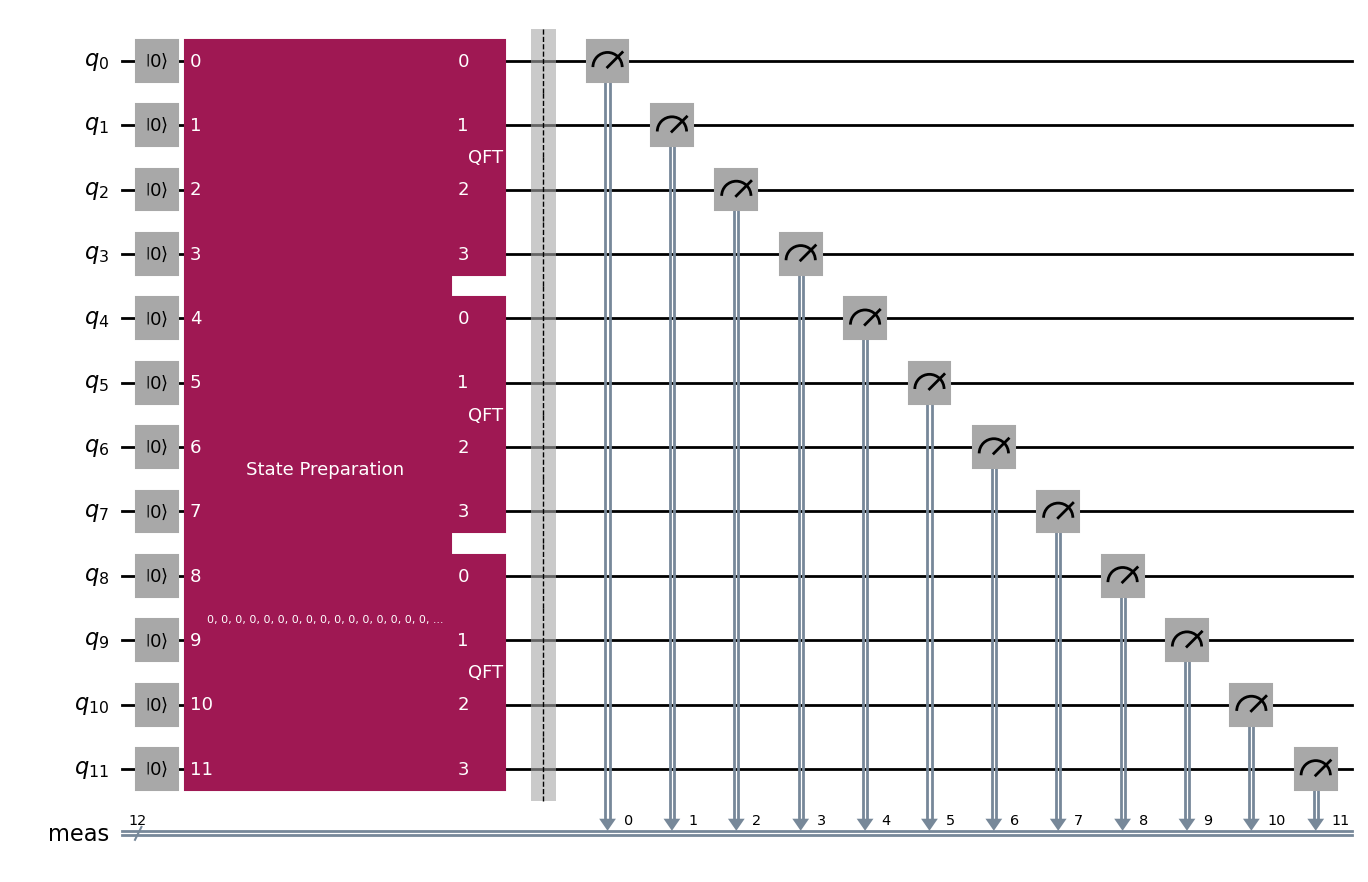

In [77]:
circ = QuantumCircuit(N_QUBITS)
circ.initialize(vec)
circ.append(QFT(M_QUBITS), X_REG)
circ.append(QFT(M_QUBITS), Y_REG)
circ.append(QFT(M_QUBITS), Z_REG)

if not EXACT_SIM:
    circ.measure_all()

circ.decompose().draw('mpl')

### Running the simulation

Either draw `N_SHOTS` samples from the circuit (default) or compute the
exact statevector probabilities (`EXACT_SIM = True`). The output `cnts`
is a dict mapping `'xyz'` bitstrings to either integer counts (sampling)
or float probabilities (exact). Both branches feed into the same
downstream code via the `cnt3d` rescaling cell below.

In [78]:
sampler = StatevectorSampler()

start = time.perf_counter()

if EXACT_SIM:
    result = Statevector(circ)
    cnts = result.probabilities_dict()
else:
    job = sampler.run([circ], shots=N_SHOTS)
    result = job.result()
    cnts = result[0].data['meas'].get_counts()

end = time.perf_counter()

print(f"Quantum calculation time = {end - start:.6f} seconds")
print(f"Number of distinct outcomes: {len(cnts)}")

Quantum calculation time = 42.702334 seconds
Number of distinct outcomes: 4095


## Run on a model of the real device

The cell below transpiles the circuit for `FakeMontrealV2` (an Aer model
of IBM's Montreal QPU, 27 qubits) and samples from it with
`BackendSamplerV2`. The transpiled depth blows up dramatically once basis
gates and connectivity are taken into account, so this cell is the
heavy one — the saved run took ~37,000 seconds. Skip it unless you want
the noisy-hardware comparison.

In [ ]:
from qiskit.primitives import BackendSamplerV2
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeMontrealV2

In [ ]:
backend = FakeMontrealV2()
sampler = BackendSamplerV2(backend=backend)

pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
transpiled_circ = pass_manager.run(circ)

print(f"Depth:  {transpiled_circ.depth()}")
print(f"Qubits: {transpiled_circ.num_qubits}")

start = time.perf_counter()
job = sampler.run([transpiled_circ], shots=N_SHOTS)
result = job.result()
end = time.perf_counter()

print(f"Quantum calculation time = {end - start:.6f} seconds")

cnts = result[0].data['meas'].get_counts()

## Processing results

The next three cells:

1. Reshape the measurement counts into an `(M, M, M)` reciprocal-space
   density `cnt3d`, applying the `W_NORM² / N_SHOTS` rescaling so that
   `cnt3d[k]` approximates $|\hat\rho(\mathbf{k})|^2 / M^D$ in
   charge² units.
2. Compute the classical Fourier transform `cff` of the charge
   distribution as a reference.
3. Define `compute_e_l_matrix(σ, ff)`, the reciprocal-space Ewald
   kernel that turns either `|cff|²` or `cnt3d · M^D` into the
   long-range energy $E^L$.

In [79]:
# Reconstruct the reciprocal-space probability density on the (M, M, M) grid.
# In EXACT_SIM mode, `cnts` holds exact probabilities; otherwise empirical frequencies.
counts_array = np.array([
    cnts.get(f'{i:0{M_QUBITS}b}{j:0{M_QUBITS}b}{k:0{M_QUBITS}b}', 0)
    for i in range(M) for j in range(M) for k in range(M)
]).reshape((M, M, M))

if EXACT_SIM:
    cnt3d = W_NORM**2 * counts_array
else:
    cnt3d = W_NORM**2 * counts_array / N_SHOTS

In [80]:
start = time.perf_counter()
cff = fftn(expand_pairs_to_vec(convert_input_to_pairs(inp)).reshape((M, M, M)))
end = time.perf_counter()

print(f"Classical FFT time = {end - start:.6f} seconds")

Classical FFT time = 0.003301 seconds


In [81]:
def compute_e_l_matrix(sigma: float, ff: np.ndarray) -> np.ndarray:
    """Reciprocal-space Ewald kernel applied to a |FFT(rho)|^2 grid of shape (M, M, M)."""
    k_sq = np.fromfunction(
        lambda i, j, k: (2 * np.pi / (M * step))**2 * (i*i + j*j + k*k),
        (M, M, M),
        dtype=float,
    )
    coef = np.divide(
        np.exp(-sigma**2 * k_sq / 2), k_sq,
        where=(k_sq != 0),
        out=np.zeros_like(k_sq),
    )
    return coef * ff / (2 * (M * step)**3 * eps0)


start = time.perf_counter()
e_l_classical = compute_e_l_matrix(SIGMA, np.abs(cff)**2).sum()
end = time.perf_counter()

print(f"E^L (classical) = {e_l_classical}")
print(f"Time: {end - start:.6f} sec")

E^L (classical) = 3.612205398731599e-18
Time: 0.001535 sec


## $E^S$ (real-space term, cell list)

The real-space short-range contribution is

$$ E^S \;=\; \frac{1}{4\pi\varepsilon_0}
   \sum_{\substack{i<j \\ \mathbf{n}}}
   \frac{q_i q_j}{r_{ij,\mathbf{n}}}\,
   \mathrm{erfc}\!\left(\frac{r_{ij,\mathbf{n}}}{\sigma\sqrt{2}}\right), $$

where $r_{ij,\mathbf{n}}$ is the distance between charges $i$ and $j$
with $j$ taken from periodic image $\mathbf{n}$. Pairs with
$r_{ij,\mathbf{n}} \geq$ `RCUT` are dropped (the `erfc` factor makes the
truncation error tiny).

`compute_e_s()` does this efficiently with a 3D cell list:

1. Expand the original charges into themselves plus all periodic images
   out to $n$ shells.
2. Bin all coordinates into cubic cells of side `RCUT`.
3. For each original charge, scan only its $3 \times 3 \times 3$
   neighbourhood, mask by `RCUT`, and accumulate the `erfc` term.

`Grid` (built one line above the function) is the un-normalized charge
distribution as an `(M, M, M)` array — reused by `compute_e_self`,
`dipole_moment`, and `compute_coulomb_grid`.

In [82]:
Grid = expand_pairs_to_vec(convert_input_to_pairs(inp)).reshape((M, M, M))


def compute_e_s() -> float:
    """Real-space term E^S via a 3D cell list with periodic images out to ``n`` shells."""
    # --- 1. Coordinates of the original charges and their periodic images ---
    xs, ys, zs = np.nonzero(Grid)
    q_vals = Grid[xs, ys, zs]
    original_coords = np.column_stack((xs, ys, zs)) * step

    # Image-shell offsets in 3D, excluding (0, 0, 0).
    shifts = np.arange(-n, n + 1)
    idx_x, idx_y, idx_z = np.meshgrid(shifts, shifts, shifts, indexing='ij')
    ox, oy, oz = idx_x.ravel(), idx_y.ravel(), idx_z.ravel()
    keep = ~((ox == 0) & (oy == 0) & (oz == 0))
    ox, oy, oz = ox[keep], oy[keep], oz[keep]

    box_length = M * step
    offsets = np.column_stack((ox, oy, oz)) * box_length

    image_coords = (original_coords[:, None, :] + offsets[None, :, :]).reshape(-1, 3)
    image_q = np.repeat(q_vals, len(offsets))

    final_coords = np.concatenate((original_coords, image_coords))
    final_q = np.concatenate((q_vals, image_q))

    # --- 2. Build the 3D cell grid ---
    cell_indices = np.floor(final_coords / RCUT).astype(int)

    grid_map = defaultdict(list)
    for i, c_idx in enumerate(cell_indices):
        grid_map[tuple(c_idx)].append(i)

    max_dims = cell_indices.max(axis=0) + 1
    max_r, max_c, max_h = max_dims

    grid_array = np.empty((max_r, max_c, max_h), dtype=object)
    grid_array[:] = np.frompyfunc(list, 0, 1)(np.empty((max_r, max_c, max_h), dtype=object))
    for (r, c, h), indices in grid_map.items():
        grid_array[r, c, h] = indices

    # --- 3. Energy via 3x3x3 neighborhood search ---
    coef = np.sqrt(2) * SIGMA
    total_energy = 0.0
    N_orig = len(q_vals)

    for i in range(N_orig):
        ri = original_coords[i]
        qi = q_vals[i]
        cell_r, cell_c, cell_h = cell_indices[i]

        r_start, r_end = max(0, cell_r - 1), min(max_r, cell_r + 2)
        c_start, c_end = max(0, cell_c - 1), min(max_c, cell_c + 2)
        h_start, h_end = max(0, cell_h - 1), min(max_h, cell_h + 2)

        neighborhood = grid_array[r_start:r_end, c_start:c_end, h_start:h_end]

        neighbor_indices = []
        for cell_list in neighborhood.flatten():
            neighbor_indices.extend(cell_list)
        neighbor_indices = np.array(neighbor_indices)

        # Avoid double-counting between original charges.
        target_indices = neighbor_indices[neighbor_indices > i]
        if len(target_indices) == 0:
            continue

        diff = final_coords[target_indices] - ri
        dists = np.linalg.norm(diff, axis=1)

        mask = dists < RCUT
        r_ij = dists[mask]
        qj = final_q[target_indices][mask]

        total_energy += np.sum((qi * qj / r_ij) * erfc(r_ij / coef))

    return total_energy / (4 * np.pi * eps0)


start = time.perf_counter()
e_s = compute_e_s()
end = time.perf_counter()

print(f"E^S = {e_s}")
print(f"Time: {end - start:.6f} sec")

E^S = -3.854144925521315e-17
Time: 0.052085 sec


## $E^{\mathrm{self}}$ (self-interaction)

The Gaussian charge that screens each particle in the reciprocal-space
sum interacts with itself; subtracting that spurious self-energy gives

$$ E^{\mathrm{self}} \;=\; -\frac{1}{4\pi\varepsilon_0}\,
   \frac{1}{\sigma\sqrt{2\pi}} \sum_i q_i^2. $$

`compute_e_self(charges)` evaluates this as a single vectorized
`np.sum(charges**2)`. The argument can be any array of charges (here we
pass `Grid`); zeros do not contribute.

In [83]:
def compute_e_self(charges: np.ndarray) -> float:
    """Self-interaction term E^self (vectorized sum of squared charges)."""
    sum_q2 = np.sum(charges**2)
    return -(sum_q2 / (SIGMA * np.sqrt(2) * np.sqrt(np.pi))) / (4 * np.pi * eps0)


start = time.perf_counter()
e_self = compute_e_self(Grid)
end = time.perf_counter()

print(f"E^self = {e_self}")
print(f"Time: {end - start:.6f} sec")

E^self = -4.036455480149368e-16
Time: 0.000908 sec


## $E^{\mathrm{dipole}}$ (surface correction)

When the simulation cell carries a net dipole moment, the reciprocal-space
sum (which assumes the surface at infinity is conducting, $\varepsilon_p
\to \infty$) needs a correction:

$$ E^{\mathrm{dipole}} \;=\; \frac{1}{4\pi\varepsilon_0}\,
   \frac{2\pi}{(1 + 2\varepsilon_p)\,V}\, |\mathbf{P}|^2,
   \qquad \mathbf{P} = \sum_i q_i\,\mathbf{r}_i. $$

For an overall neutral cell (e.g. the alternating-sign cluster used here)
$\mathbf{P} = \mathbf{0}$ and `E^dipole` is zero. The implementation
computes each component $P_\alpha$ as
`grid.sum(over the two axes orthogonal to α) @ coords`, which is the
vectorized form of $\sum_i q_i\,r_i^\alpha$.

In [84]:
def dipole_moment(grid_data: np.ndarray) -> float:
    """Surface (dipole) correction term E^dipole."""
    grid_data = grid_data.astype(float)
    coords = (np.arange(M) * step).astype(float)

    # P_alpha = sum over charges of q_i * r_i_alpha. Reduce over the two axes
    # orthogonal to alpha, then take the dot product with the 1D coordinate axis.
    Px = np.dot(grid_data.sum(axis=(1, 2)), coords)
    Py = np.dot(grid_data.sum(axis=(0, 2)), coords)
    Pz = np.dot(grid_data.sum(axis=(0, 1)), coords)

    P_sq = Px**2 + Py**2 + Pz**2
    return (2 * np.pi / ((1 + 2 * epsp) * (M * step)**3 * 4 * np.pi * eps0)) * P_sq


start = time.perf_counter()
e_dipole = dipole_moment(Grid)
end = time.perf_counter()

print(f"E^dipole = {e_dipole}")
print(f"Time: {end - start:.6f} sec")

E^dipole = 2.305925758602517e-19
Time: 0.001554 sec


## Total PME energy (classical reference)

Recompute all four terms in one cell so that timings and intermediate
values are produced together, and sum them into

$$ E_{\mathrm{PME}} \;=\; E^L \;+\; E^S \;+\; E^{\mathrm{self}} \;+\; E^{\mathrm{dipole}}, $$

using the classical FFT for $E^L$. This is the all-classical baseline
that the quantum result will be compared against.

In [85]:
start = time.perf_counter()

cff           = fftn(expand_pairs_to_vec(convert_input_to_pairs(inp)).reshape((M, M, M)))
e_l_classical = compute_e_l_matrix(SIGMA, np.abs(cff)**2).sum()
e_s           = compute_e_s()
e_self        = compute_e_self(Grid)
e_dipole      = dipole_moment(Grid)

end = time.perf_counter()

E_PME = e_s + e_l_classical + e_self + e_dipole

print(f"PME calculation time = {end - start:.6f} seconds\n")
print(f"E_PME    = {E_PME}")
print(f"E^L      = {e_l_classical}")
print(f"E^S      = {e_s}")
print(f"E^self   = {e_self}")
print(f"E^dipole = {e_dipole}")

PME calculation time = 0.068760 seconds

E_PME    = -4.383441992955581e-16
E^L      = 3.612205398731599e-18
E^S      = -3.854144925521315e-17
E^self   = -4.036455480149368e-16
E^dipole = 2.305925758602517e-19


## Quantum vs classical $E^L$

The next cell repeats the $E^L$ calculation using the quantum-measured
density `cnt3d` instead of the classical FFT. Because the quantum state
is L2-normalized and probabilities sum to one, the recovered magnitude
differs from $|\hat\rho(\mathbf{k})|^2$ by exactly a factor of $M^D$,
which is restored here:

```
e_l_quantum = compute_e_l_matrix(SIGMA, cnt3d).sum() * (M * M * M)
```

The cell also assembles `E_quantum = e_l_quantum + e_s + e_self + e_dipole`
— the same total as $E_{\mathrm{PME}}$ but with $E^L$ replaced — and
reports the gap $|E_{\mathrm{quantum}} - E_{\mathrm{PME}}|$, which is
entirely due to shot noise (and, if the FakeMontreal/Sherbrooke cells
were run, hardware noise).

In [86]:
e_l_quantum = compute_e_l_matrix(SIGMA, cnt3d).sum() * (M * M * M)
E_quantum   = e_l_quantum + e_s + e_self + e_dipole

print(f"E^L (quantum)   = {e_l_quantum}")
print(f"E^L (classical) = {e_l_classical}")
print(f"|q - c|         = {abs(e_l_quantum - e_l_classical)}\n")
print(f"E_PME (quantum) = {E_quantum}")
print(f"Quantum error   = {np.abs(E_quantum - E_PME)}")

E^L (quantum)   = 3.586765178983079e-18
E^L (classical) = 3.612205398731599e-18
|q - c|         = 2.5440219748519985e-20

E_PME (quantum) = -4.3836963951530663e-16
Quantum error   = 2.544021974855003e-20


## Direct Coulomb summation (ground truth)

A straightforward $\mathcal{O}(N^2)$ Coulomb sum, used as the reference
against which both Ewald variants are scored. Pairs are summed within
the unit cell ($i < j$, to avoid double-counting) and between the unit
cell and its periodic images out to $m$ shells:

$$ E_{\mathrm{Coulomb}} \;=\;
   \frac{1}{4\pi\varepsilon_0}\!
   \left[\sum_{i<j} \frac{q_i q_j}{r_{ij}}
   \;+\; \sum_{i,j,\,\mathbf{n}\neq 0} \frac{q_i q_j}{r_{ij,\mathbf{n}}}\right]. $$

This is feasible only because the test configurations are small. It
scales as $N^2 \cdot (2m+1)^3$ and becomes prohibitive for large
systems — which is the whole reason Ewald summation exists.

In [87]:
def compute_coulomb_grid(grid: np.ndarray, m: int, M: int, step: float, eps0: float) -> float:
    """Direct O(N^2) Coulomb sum over the unit cell plus m image shells, used as ground truth."""
    # 1. Coordinates and charges in the unit cell.
    xs, ys, zs = np.nonzero(grid)
    q_initial = grid[xs, ys, zs]
    coords_initial = np.stack([xs, ys, zs], axis=1).astype(float)

    # 2. Periodic-image offsets, excluding the (0, 0, 0) cell.
    offsets = np.arange(-m, m + 1)
    mx, my, mz = np.meshgrid(offsets, offsets, offsets)
    shift_indices = np.stack([mx.ravel(), my.ravel(), mz.ravel()], axis=1)
    shift_indices = shift_indices[~np.all(shift_indices == 0, axis=1)]

    charges_coords = []
    charges_q = []
    for s in shift_indices:
        charges_coords.append(coords_initial + s * M)
        charges_q.append(q_initial)
    coords_periodic = np.vstack(charges_coords)
    q_periodic = np.concatenate(charges_q)

    # 3. Unit cell <-> periodic images.
    dist_matrix = cdist(coords_initial * step, coords_periodic * step, metric='euclidean')
    summ = np.sum((q_initial[:, np.newaxis] * q_periodic) / dist_matrix)

    # 4. Self-interaction within the unit cell (i < j to avoid double counting).
    dist_internal = cdist(coords_initial * step, coords_initial * step, metric='euclidean')
    i, j = np.triu_indices(len(q_initial), k=1)
    internal_summ = np.sum((q_initial[i] * q_initial[j]) / dist_internal[i, j])

    return (summ + internal_summ) / (4 * np.pi * eps0)


start = time.perf_counter()
e_coulomb = compute_coulomb_grid(Grid, m, M, step, eps0)
end = time.perf_counter()

print(f"E_Coulomb = {e_coulomb}")
print(f"Time: {end - start:.6f} sec")

E_Coulomb = -4.384340898640361e-16
Time: 0.038139 sec


## Final comparison

Compute the absolute deltas $E_{\mathrm{PME}} - E_{\mathrm{Coulomb}}$ and
$E_{\mathrm{quantum}} - E_{\mathrm{Coulomb}}$, and the dimensionless
relative errors

$$ \mathrm{rms}_E \;=\; \sqrt{
   \frac{\bigl(E_{\mathrm{Coulomb}} - E_{\mathrm{candidate}}\bigr)^2}
        {E_{\mathrm{Coulomb}}^2}
   }. $$

`rms_E (classical)` is the floor (Ewald truncation + FFT discretization
error). `rms_E (quantum)` adds the shot-noise contribution from the
measurement-based reconstruction of $|\hat\rho(\mathbf{k})|^2$.

In [88]:
delta_E   = E_PME     - e_coulomb
delta_E_q = E_quantum - e_coulomb

print(f"E_PME      - E_Coulomb = {delta_E}")
print(f"E_quantum  - E_Coulomb = {delta_E_q}\n")
print(f"rms_E (classical) = {np.sqrt((e_coulomb - E_PME)**2 / e_coulomb**2)}")
print(f"rms_E (quantum)   = {np.sqrt((e_coulomb - E_quantum)**2 / e_coulomb**2)}")

E_PME      - E_Coulomb = 8.989056847800516e-20
E_quantum  - E_Coulomb = 6.445034872945513e-20

rms_E (classical) = 0.00020502641230722127
rms_E (quantum)   = 0.000147001225998284


## Quantum circuit complexity

The depth of the circuit is the number of "layers". This definition depends on the set of allowed gates, the number of available qubits (we can use free qubits as ancillae to simplify certain gates), and the QPU topology (e.g. if we allow any state preparation and QFT gates, we get the depth = 3). Therefore, we have to fix the quantum chip, which also fixes the allowed gates and the topology.

Here, we compile the original circuit for the "Sherbrooke" QPU (it has 127 qubits) from IBM.

In [90]:
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit.transpiler import generate_preset_pass_manager


backend = FakeSherbrooke()
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
transpiled_circ = pass_manager.run(circ)

print(f"Original circuit depth: {circ.depth()}")
print(f"Compiled circuit depth: {transpiled_circ.depth()}")

Original circuit depth: 3
Compiled circuit depth: 30333
